# 관련 단축키 설명

## 1. 셀 코드 실행

Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

Alt + Enter: 현재 셀을 실행하고 바로 아래에 새로운 코드 셀을 추가합니다. (Mac: Option + Enter)

## 2. 셀 삭제

명령 모드(Esc) 상태에서:

D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

## 3. 코드 셀 만들기

명령 모드(Esc) 상태에서:

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

## 4. 마크다운 셀 만들기

명령 모드(Esc) 상태에서:

M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

실전 팁: 보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용합니다. 실수로 셀을 지웠다면 당황하지 말고 Z 키를 누르면 방금 삭제한 셀이 복구됩니다.

---

# 비전 노드 개발 관련 실험코드.

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

---

## **리얼센스 카메라 인식 하는 함수**

In [2]:
import os
import time
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt

In [ ]:
# import pyrealsense2 as rs


def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [ ]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: /sys/devices/pci0000:00/0000:00:14.0/usb2/2-8/2-8:1.0/video4linux/video0
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


## **카메라에서 640 480 기준의 칼라, 뎁스 이미지 인트린직 요청**

In [10]:
def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, depth image를 1장 캡처하고,
    color/depth intrinsics(fx, fy, cx, cy)를 출력 및 yaml로 저장한다.

    Returns
    -------
    image_bgr : np.ndarray
        OpenCV용 BGR 컬러 이미지

    depth_image : np.ndarray
        uint16 depth 이미지. 단위는 보통 raw depth unit이며,
        실제 meter 변환은 depth_scale을 곱해야 함.

    intrinsics_dict : dict
        color/depth intrinsics와 depth_scale 정보
    """

    import os
    import yaml
    import cv2
    import numpy as np
    import pyrealsense2 as rs
    import matplotlib.pyplot as plt

    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]

    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)

    config.enable_stream(
        rs.stream.color,
        width,
        height,
        rs.format.bgr8,
        fps
    )

    config.enable_stream(
        rs.stream.depth,
        width,
        height,
        rs.format.z16,
        fps
    )

    try:
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # stream profile에서 intrinsics 가져오기
        color_stream = profile.get_stream(rs.stream.color).as_video_stream_profile()
        depth_stream = profile.get_stream(rs.stream.depth).as_video_stream_profile()

        color_intr = color_stream.get_intrinsics()
        depth_intr = depth_stream.get_intrinsics()

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx}")
        print(f"fy     : {color_intr.fy}")
        print(f"cx     : {color_intr.ppx}")
        print(f"cy     : {color_intr.ppy}")

        print("\n[DEPTH INTRINSICS]")
        print(f"width  : {depth_intr.width}")
        print(f"height : {depth_intr.height}")
        print(f"fx     : {depth_intr.fx}")
        print(f"fy     : {depth_intr.fy}")
        print(f"cx     : {depth_intr.ppx}")
        print(f"cy     : {depth_intr.ppy}")

        # 자동 노출 안정화를 위해 몇 프레임 버림
        for _ in range(warmup_frames):
            pipeline.wait_for_frames()

        frames = pipeline.wait_for_frames()

        color_frame = frames.get_color_frame()
        depth_frame = frames.get_depth_frame()

        if not color_frame:
            raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")

        if not depth_frame:
            raise RuntimeError("뎁스 프레임을 가져오지 못했습니다.")

        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # 저장 폴더 생성
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    # 컬러 이미지 저장
    success_color = cv2.imwrite(image_save_path, image_bgr)
    if not success_color:
        raise IOError(f"컬러 이미지 저장 실패: {image_save_path}")

    # depth raw 저장
    # uint16 png로 저장됨
    success_depth = cv2.imwrite(depth_save_path, depth_image)
    if not success_depth:
        raise IOError(f"뎁스 이미지 저장 실패: {depth_save_path}")

    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 raw 이미지 저장 완료: {depth_save_path}")
    print(f"[INFO] color image shape: {image_bgr.shape}")
    print(f"[INFO] depth image shape: {depth_image.shape}")
    print(f"[INFO] depth dtype: {depth_image.dtype}")

    intrinsics_dict = {
        "device": {
            "serial_number": serial_number
        },
        "color": {
            "width": int(color_intr.width),
            "height": int(color_intr.height),
            "fx": float(color_intr.fx),
            "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx),
            "cy": float(color_intr.ppy),
            "model": str(color_intr.model),
            "coeffs": [float(v) for v in color_intr.coeffs]
        },
        "depth": {
            "width": int(depth_intr.width),
            "height": int(depth_intr.height),
            "fx": float(depth_intr.fx),
            "fy": float(depth_intr.fy),
            "cx": float(depth_intr.ppx),
            "cy": float(depth_intr.ppy),
            "model": str(depth_intr.model),
            "coeffs": [float(v) for v in depth_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    # YAML 저장
    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(
            intrinsics_dict,
            f,
            allow_unicode=True,
            sort_keys=False,
            default_flow_style=False
        )

    print(f"[INFO] intrinsics YAML 저장 완료: {yaml_save_path}")

    if show:
        # 컬러 이미지: BGR -> RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # depth 시각화용 컬러맵
        depth_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_image, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_colormap_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

        # 표시할 intrinsics 텍스트 구성
        intr_text = (
            "[COLOR INTRINSICS]\n"
            f"width  : {color_intr.width}\n"
            f"height : {color_intr.height}\n"
            f"fx     : {color_intr.fx:.3f}\n"
            f"fy     : {color_intr.fy:.3f}\n"
            f"cx     : {color_intr.ppx:.3f}\n"
            f"cy     : {color_intr.ppy:.3f}\n\n"
            "[DEPTH INTRINSICS]\n"
            f"width  : {depth_intr.width}\n"
            f"height : {depth_intr.height}\n"
            f"fx     : {depth_intr.fx:.3f}\n"
            f"fy     : {depth_intr.fy:.3f}\n"
            f"cx     : {depth_intr.ppx:.3f}\n"
            f"cy     : {depth_intr.ppy:.3f}\n\n"
            "[DEPTH SCALE]\n"
            f"{depth_scale:.8f} m/unit"
        )

        # 1행 3열: Intrinsics | Color | Depth
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(18, 5),
            gridspec_kw={"width_ratios": [1.1, 2, 2]}
        )

        # 왼쪽: intrinsics 텍스트
        axes[0].axis("off")
        axes[0].set_title("Camera Intrinsics")
        axes[0].text(
            0.0,
            0.95,
            intr_text,
            fontsize=10,
            family="monospace",
            verticalalignment="top"
        )

        # 가운데: color image
        axes[1].imshow(image_rgb)
        axes[1].set_title("Color Image")
        axes[1].axis("off")

        # 오른쪽: depth image
        axes[2].imshow(depth_colormap_rgb)
        axes[2].set_title("Depth Image")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return image_bgr, depth_image, intrinsics_dict

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.1939697265625
fy     : 606.0857543945312
cx     : 329.0955810546875
cy     : 247.07073974609375

[DEPTH INTRINSICS]
width  : 640
height : 480
fx     : 385.48712158203125
fy     : 385.48712158203125
cx     : 325.4142761230469
cy     : 242.95050048828125

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 raw 이미지 저장 완료: output/realsense_depth_raw.png
[INFO] color image shape: (480, 640, 3)
[INFO] depth image shape: (480, 640)
[INFO] depth dtype: uint16
[INFO] intrinsics YAML 저장 완료: output/realsense_intrinsics.yaml


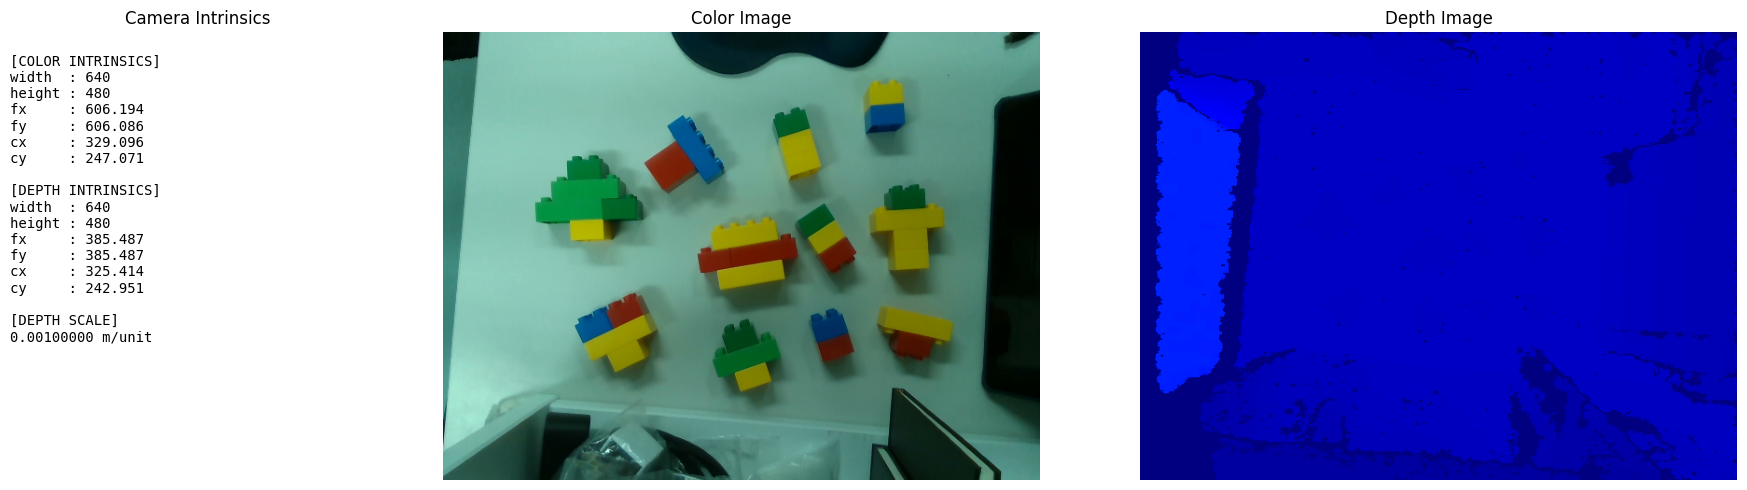

In [11]:
color_img, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

## **binaryzation first**

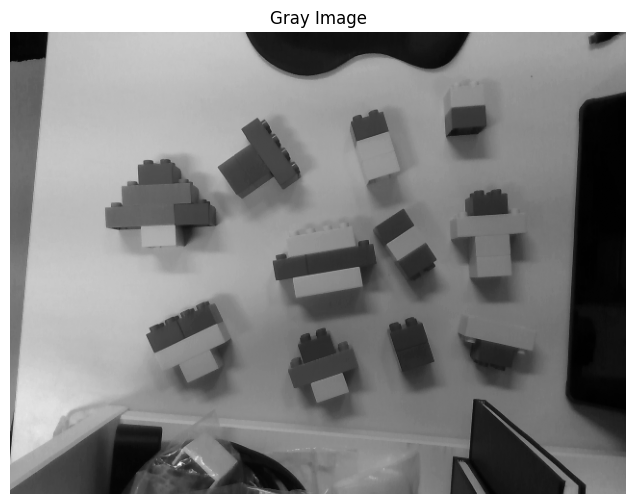

In [17]:
gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Gray Image")
plt.axis("off")
plt.show()

# 기법: Gaussian Blur

카메라 이미지에는 조명 변화, 센서 노이즈, 표면 반사 등으로 인해 작은 점 잡음이나 불규칙한 픽셀 변화가 포함될 수 있다.  
이러한 노이즈는 이진화, 엣지 검출, contour 추출 과정에서 불필요한 경계로 검출될 수 있다.

$$
I_{blur}(x, y) = G_{\sigma}(x, y) * I(x, y)
$$

Gaussian Blur는 가우시안 커널을 이미지에 컨볼루션하여 주변 픽셀과의 가중 평균을 계산하는 평활화 기법이다.  
중심 픽셀에 가까운 값일수록 큰 가중치를 가지며, 멀어질수록 작은 가중치를 갖는다.  
이를 통해 작은 노이즈를 줄이고 이미지의 급격한 밝기 변화를 완화할 수 있다.  
다만 커널 크기나 $\sigma$ 값이 커지면 객체의 경계도 함께 흐려질 수 있다.  
본 과정에서는 후속 이진화와 경계 검출을 안정화하기 위한 전처리로 사용한다.

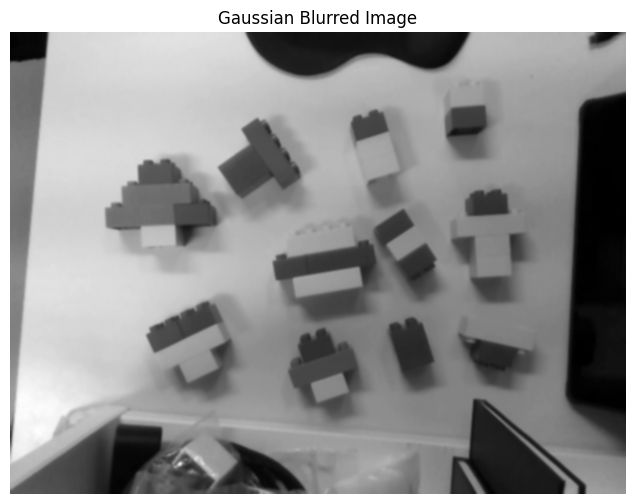

In [20]:
blurred = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),
    sigmaX=0
)

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

# 기법: CLAHE

조명 불균일, 반사, 그림자 등으로 인해 grayscale 이미지의 일부 영역에서 명암 대비가 낮아질 수 있다.  
이 경우 객체의 경계나 표면 특징이 약해져 후속 이진화, 엣지 검출, 마스크 생성이 불안정해질 수 있다.

$$
I_{CLAHE}(x, y) = T_{local}(I(x, y))
$$

CLAHE는 이미지를 작은 타일 영역으로 나누고 각 영역마다 히스토그램 평활화를 수행한다.  
일반 히스토그램 평활화와 달리 국소 영역의 대비를 향상시키는 데 유리하다.  
`clipLimit`은 특정 밝기 구간이 과도하게 증폭되는 것을 제한한다.  
`tileGridSize`는 이미지를 나누는 지역 영역의 크기를 의미한다.  
본 과정에서는 grayscale 이미지에 CLAHE를 적용하여 객체 경계와 표면 명암 차이를 강화한다.

In [18]:
def apply_clahe_to_gray_image(
    gray_img,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=True
):
    """
    Grayscale 이미지에 CLAHE를 적용하는 함수.

    Parameters
    ----------
    gray_img : np.ndarray
        입력 grayscale 이미지
    clip_limit : float
        대비 제한 값
    tile_grid_size : tuple
        CLAHE 타일 크기
    show : bool
        True이면 원본과 결과를 좌우로 출력

    Returns
    -------
    clahe_img : np.ndarray
        CLAHE 적용 결과 이미지
    """

    if gray_img is None:
        raise ValueError("gray_img가 None입니다.")

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    clahe_img = clahe.apply(gray_img)

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(gray_img, cmap="gray")
        axes[0].set_title("Original Gray")
        axes[0].axis("off")

        axes[1].imshow(clahe_img, cmap="gray")
        axes[1].set_title("CLAHE Result")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return clahe_img

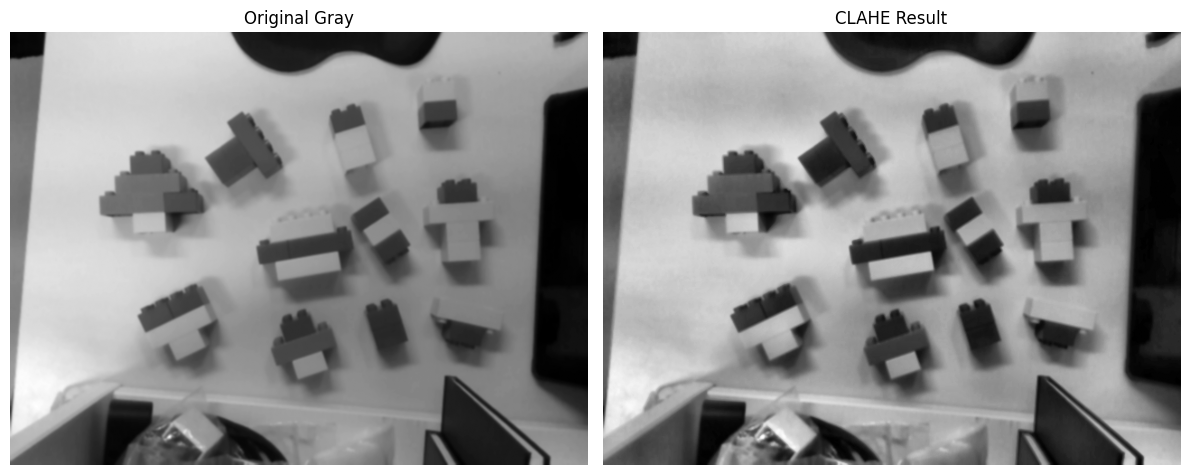

In [21]:
clahe_img = apply_clahe_to_gray_image(
    gray_img=blurred,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=True
)

# 기법: Canny Edge Detection

CLAHE를 통해 국소 대비가 향상된 이미지에서는 객체 경계와 명암 변화가 더 뚜렷하게 나타난다.  
Canny Edge Detection은 이러한 밝기 변화가 큰 지점을 이용해 객체의 경계 후보를 검출하기 위해 사용한다.

$$
G = \sqrt{G_x^2 + G_y^2}
$$

Canny Edge Detection은 이미지의 gradient를 계산하여 밝기 변화가 큰 영역을 찾는다.  
이후 non-maximum suppression을 통해 경계를 얇게 만들고, 이중 임계값을 이용해 강한 경계와 약한 경계를 구분한다.  
`threshold1`은 약한 edge 기준값이고, `threshold2`는 강한 edge 기준값이다.  
두 값이 낮으면 edge가 많이 검출되고, 높으면 강한 경계만 남는다.  
본 과정에서는 CLAHE 결과 이미지에서 객체의 외곽선과 내부 경계 후보를 확인하는 용도로 사용한다.

In [22]:
def apply_canny_edge(
    input_img,
    threshold1=50,
    threshold2=150,
    aperture_size=3,
    L2gradient=True,
    show=True
):
    """
    입력 grayscale 이미지에 Canny Edge Detection을 적용하는 함수.

    Parameters
    ----------
    input_img : np.ndarray
        입력 grayscale 이미지. 예: clahe_img
    threshold1 : int
        낮은 임계값
    threshold2 : int
        높은 임계값
    aperture_size : int
        Sobel 연산 커널 크기. 보통 3 사용.
    L2gradient : bool
        True이면 더 정확한 gradient magnitude 계산 사용.
    show : bool
        True이면 입력 이미지와 Canny 결과를 좌우로 표시.

    Returns
    -------
    canny_edges : np.ndarray
        Canny edge 결과 이미지. uint8, 0 또는 255.
    """

    import cv2
    import matplotlib.pyplot as plt

    if input_img is None:
        raise ValueError("input_img가 None입니다.")

    canny_edges = cv2.Canny(
        input_img,
        threshold1=threshold1,
        threshold2=threshold2,
        apertureSize=aperture_size,
        L2gradient=L2gradient
    )

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(input_img, cmap="gray")
        axes[0].set_title("Input Image")
        axes[0].axis("off")

        axes[1].imshow(canny_edges, cmap="gray")
        axes[1].set_title(f"Canny Edge ({threshold1}, {threshold2})")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return canny_edges

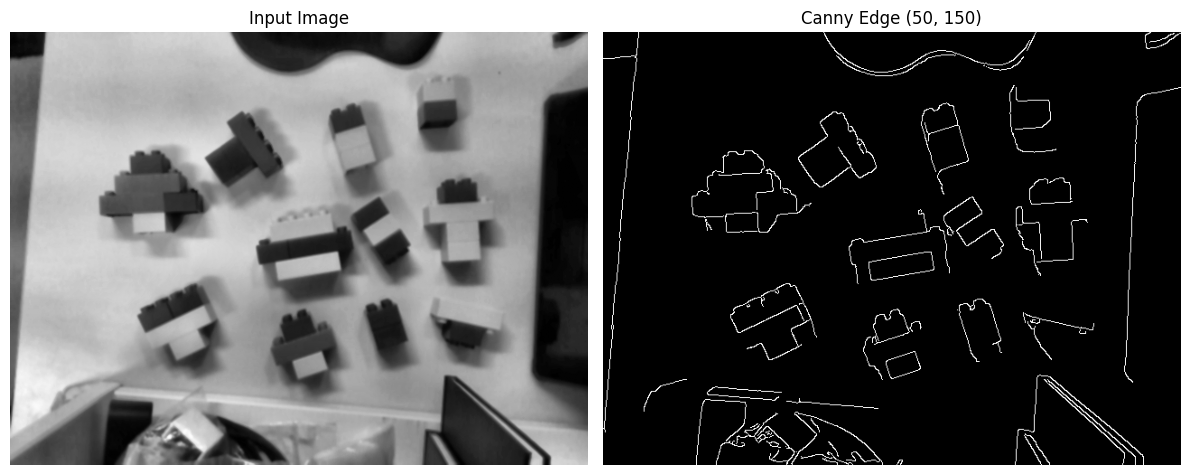

In [28]:
canny_edges = apply_canny_edge(
    input_img=clahe_img,
    threshold1=50,
    threshold2=150,
    aperture_size=3,
    L2gradient=True,
    show=True
)